# Course Project: Stock Market Analysis with LLM Classification and Machine Learning

## How to run this notebook

1. Install the Python packages (if not already installed): pandas, numpy, matplotlib, seaborn, scikit-learn, ollama. You can install them all at once with: pip install pandas numpy matplotlib seaborn scikit-learn ollama

2. Install Ollama from https://ollama.com. On Windows and Mac it starts automatically after install, on Linux you run "ollama serve" in a terminal.

3. Pull the model used in this notebook (only needed once, downloads about 3 GB): ollama pull gemma3:4b

4. Download the dataset called "top_10_stock_data.csv" from Kaggle and put it in the same folder as this notebook: https://www.kaggle.com/datasets/umerhaddii/top-10-global-companies-stock-data-2024

5. Run all cells from top to bottom. Note that the LLM classification step takes around 15-20 minutes since gemma3:4b runs on CPU. The notebook creates an exports folder with the cleaned data, model results, and LLM classifications.

## AI Usage Statement

I used Claude to help with debugging and to discuss the project structure after choosing the topic myself. Every part of the code was reviewed and tested by me. I did the analysis and wrote the comments myself, using Claude as an assistant for ideas when needed.

## Pipeline

![Pipeline](pipeline.png)

## Introduction

The goal of this project is to analyse the stock performance of nine large global companies between 2015 and 2024 and to use a local LLM to classify each company-year into a market regime label (Bull, Bear, Volatile, or Stable).

I want to investigate:
- How returns and volatility differ across companies and years
- Whether the regime labels, classified by an LLM, match what the numbers suggest
- Whether a simple regression model can predict yearly returns from volatility, regime, and a few other features

The dataset used is the "Top 10 Global Companies Stock Data 2024" from Kaggle.

## Data Loading and Raw Data Export

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("top_10_stock_data.csv", parse_dates=["Date"])

df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.373959,212818400
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.687313,257142000
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.689535,263188400
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,24.021711,160423600
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.944679,237458000


In [ ]:
# Saudi Aramco (2222.SR) trades on a different exchange and GOOG is a duplicate share class of GOOGL
df = df[~df["Ticker"].isin(["2222.SR", "GOOG"])]
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Tickers:", sorted(df["Ticker"].unique()))
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

Shape: (21879, 8)
Tickers: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'LLY', 'META', 'MSFT', 'NVDA', 'TSM']
Date range: 2015-01-02 to 2024-08-29


In [ ]:
# Checking for missing values, should be 0
df.isnull().sum()

Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [ ]:
# Exporting raw data so peer reviewers can rerun without redownloading from Kaggle
os.makedirs("exports", exist_ok=True)
df.to_csv("exports/raw_prices.csv", index=False)

In [39]:
# If you want to rerun the notebook from the saved CSV instead of the original Kaggle file, uncomment the line below and re-run from this point onwards.

# df = pd.read_csv("exports/raw_prices.csv", parse_dates=["Date"])

## Data Cleaning and Transformation

I keep the columns I actually need, then compute daily returns and 20-day rolling volatility per ticker. After that I aggregate everything to one row per ticker per year, which is what the LLM and the regression model will work with.

In [7]:
df = df[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]
df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,212818400
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,257142000
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,263188400
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,160423600
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,237458000


In [10]:
# Daily return = (today_close - yesterday_close) / yesterday_close
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()

# Rolling 20-day volatility, annualised (sqrt of 252 trading days)
df["Volatility_20d"] = df.groupby("Ticker")["Daily_Return"].transform(
    lambda x: x.rolling(20, min_periods=5).std()
) * np.sqrt(252)

df[df["Ticker"] == "AAPL"].head(10)

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return,Volatility_20d
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,212818400,NaN,NaN
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,257142000,-0.028172,NaN
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,263188400,0.000094,NaN
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,160423600,0.014022,NaN
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,237458000,0.038422,NaN
5,2015-01-09,AAPL,28.167500,28.312500,27.552500,28.002501,214798000,0.001073,0.383810
6,2015-01-12,AAPL,28.150000,28.157499,27.200001,27.312500,198603200,-0.024641,0.393659
7,2015-01-13,AAPL,27.857500,28.200001,27.227501,27.555000,268367600,0.008879,0.363171
8,2015-01-14,AAPL,27.260000,27.622499,27.125000,27.450001,195826400,-0.003811,0.337492
9,2015-01-15,AAPL,27.500000,27.514999,26.665001,26.705000,240056000,-0.027140,0.348450


The first 5 rows show NaN in Volatility_20d. The rolling window needs at least 5 valid daily returns before it can calculate. Also row 0 has NaN as its daily return since there's no previous day to compare to. From row 5 onwards I get real values.

In [11]:
# Aggregate to one row per ticker per year
df["Year"] = df["Date"].dt.year

yearly = df.groupby(["Ticker", "Year"]).agg(
    start_price=("Close", "first"),
    end_price=("Close", "last"),
    mean_volatility=("Volatility_20d", "mean"),
    max_drawdown=("Daily_Return", "min"),
    best_day=("Daily_Return", "max")
).reset_index()

yearly["yearly_return"] = (yearly["end_price"] - yearly["start_price"]) / yearly["start_price"]

yearly = yearly.round(4)
yearly.head(10)

,Ticker,Year,start_price,end_price,mean_volatility,max_drawdown,best_day,yearly_return
0,AAPL,2015,27.3325,26.3150,0.2602,-0.0612,0.0574,-0.0372
1,AAPL,2016,26.3375,28.9550,0.2225,-0.0657,0.0650,0.0994
2,AAPL,2017,29.0375,42.3075,0.1668,-0.0388,0.0610,0.4570
3,AAPL,2018,43.0650,39.4350,0.2561,-0.0663,0.0704,-0.0843
4,AAPL,2019,39.4800,73.4125,0.2562,-0.0996,0.0683,0.8595
5,AAPL,2020,75.0875,132.6900,0.4139,-0.1286,0.1198,0.7671
6,AAPL,2021,129.4100,177.5700,0.2434,-0.0417,0.0539,0.3722
7,AAPL,2022,182.0100,129.9300,0.3472,-0.0587,0.0890,-0.2861
8,AAPL,2023,125.0700,192.5300,0.2047,-0.0480,0.0469,0.5394
9,AAPL,2024,185.6400,229.7900,0.2354,-0.0482,0.0726,0.2378


## API Component: Doing Market Regime Classification With An LLM

We use Ollama as a local LLM API. The model takes a one-line summary of each ticker-year (return, volatility, biggest drop, biggest gain) and classifies it into one of four market regimes: Bull, Bear, Volatile, or Stable. Since Ollama runs locally, no API key is needed. We used the gemma3:4b model

In [ ]:
# Setting up Ollama
%pip install ollama
!ollama pull gemma3:4b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling aeda25e63ebd: 100% ▕██████████████████▏ 3.3 GB                         
pulling e0a42594d802: 100% ▕██████████████████▏  358 B                         
pulling dd084c7d92a3: 100% ▕██████████████████▏ 8.4 KB                         
pulling 3116c5225075: 100% ▕██████████████████▏   77 B                         
pulling b6ae5839783f: 100% ▕██████████████████▏  489 B                         
verifying sha256 digest 
writing manifest 
success 


In [ ]:
# Importing Ollama and connecting to LLM
import ollama
def ask_llm(prompt, model):
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response["message"]["content"]
# Quick test
print(ask_llm("What is the biggest planet? One word.", "gemma3:4b"))

Jupiter


### Defining the classification function

The function takes a ticker-year summary, feeds it to gemma3:4b through Ollama, and gets back one of Bull, Bear, Volatile, or Stable. The summary looks like "AAPL in 2015: yearly return -3.7%, average volatility 26%, biggest single-day drop -6.1%, biggest single-day gain +5.7%."

In [18]:
def classify_regime(row, model):
    summary = (
        f"Ticker {row['Ticker']} in {row['Year']}: "
        f"yearly return {row['yearly_return']:+.1%}, "
        f"average volatility {row['mean_volatility']:.1%}, "
        f"biggest single-day drop {row['max_drawdown']:+.1%}, "
        f"biggest single-day gain {row['best_day']:+.1%}."
    )

    prompt = (
        f"Classify the following stock year as exactly one word: "
        f"Bull, Bear, Volatile, or Stable.\n\n"
        f"{summary}"
    )

    result = ask_llm(prompt, model).strip()

    valid = ["Bull", "Bear", "Volatile", "Stable"]
    for label in valid:
        if label.lower() in result.lower():
            return label
    return "Stable"


In [22]:
# Testing, testing on the first row
print("Testing on:")
display(yearly.iloc[[0]])
classify_regime(yearly.iloc[0], "gemma3:4b")

Testing on:


,Ticker,Year,start_price,end_price,mean_volatility,max_drawdown,best_day,yearly_return,regime
0,AAPL,2015,27.3325,26.315,0.2602,-0.0612,0.0574,-0.0372,Bear


'Bear'

The LLM Gemma3:4b labelled AAPL 2015 as Bear. It does fit the numbers because its a small negative return and a rough drawdown day.

In [ ]:
# Applying it to all ticker-years, this takes very long as I warned before 
yearly["regime"] = yearly.apply(lambda row: classify_regime(row, "gemma3:4b"), axis=1)

yearly[["Ticker", "Year", "yearly_return", "mean_volatility", "regime"]].head(10)

,Ticker,Year,yearly_return,mean_volatility,regime
0,AAPL,2015,-0.0372,0.2602,Bear
1,AAPL,2016,0.0994,0.2225,Bull
2,AAPL,2017,0.4570,0.1668,Bull
3,AAPL,2018,-0.0843,0.2561,Bear
4,AAPL,2019,0.8595,0.2562,Bull
5,AAPL,2020,0.7671,0.4139,Bull
6,AAPL,2021,0.3722,0.2434,Bull
7,AAPL,2022,-0.2861,0.3472,Bear
8,AAPL,2023,0.5394,0.2047,Bull
9,AAPL,2024,0.2378,0.2354,Bull


This took around 19 minutes since gemma3:4b is a fairly large model and we make about 90 calls on CPU. But we can see that it worked with Apples yearly data as an example.

In [ ]:
# Saving LLM classifications to exports
yearly.to_csv("exports/yearly_with_regimes.csv", index=False)

## Visual and Quantitative Analysis

In this section I look at the yearly data both visually and with a simple regression model. The goal is to see how returns and volatility differ across tickers and years, whether the LLM labels line up with the numbers, and how much of the yearly return can be explained by volatility and the regime label.

In [24]:
# Summary statistics for closing prices grouped by ticker
print("Summary Statistics: Closing Price (USD) by Ticker")
df.groupby("Ticker")["Close"].describe().round(2)

Summary Statistics: Closing Price (USD) by Ticker


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2431.0,91.59,61.07,22.58,36.64,60.79,148.94,234.82
AMZN,2431.0,97.79,51.74,14.35,47.88,93.41,148.38,200.00
BRK-B,2431.0,233.77,80.30,124.13,169.90,208.94,290.21,468.37
GOOGL,2431.0,79.63,41.15,24.85,46.98,62.30,114.77,191.18
LLY,2431.0,218.95,201.65,65.97,82.77,123.06,286.32,954.48
META,2431.0,209.93,103.93,74.05,133.85,180.82,269.42,539.91
MSFT,2431.0,179.39,116.53,40.29,69.41,141.07,271.50,467.56
NVDA,2431.0,16.92,25.03,0.48,3.38,6.26,19.31,135.58
TSM,2431.0,66.17,39.51,18.76,35.24,48.75,96.38,191.05


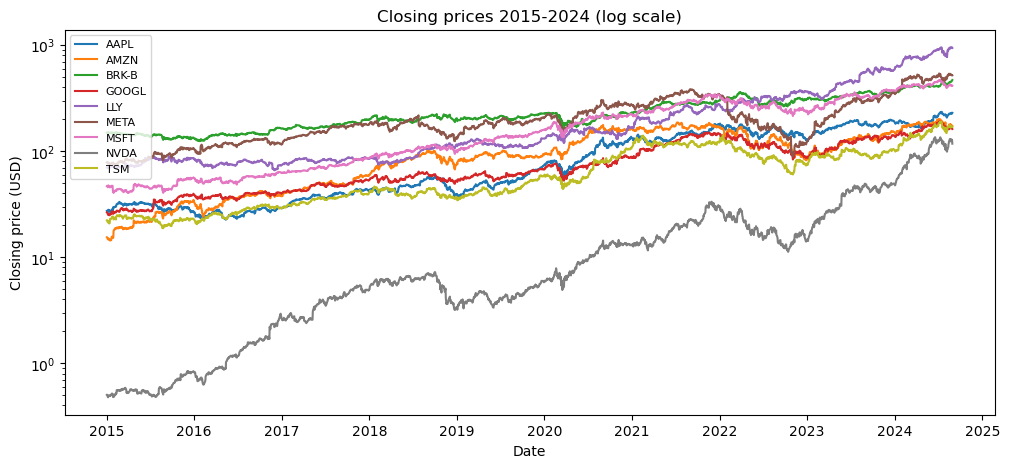

In [ ]:
# Plot 1: closing prices over time, I use log scale so all stocks fit on the same axis
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="Date", y="Close", hue="Ticker")
plt.yscale("log")
plt.title("Closing prices 2015-2024 (log scale)")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")
plt.legend(loc="upper left", fontsize=8)
plt.show()

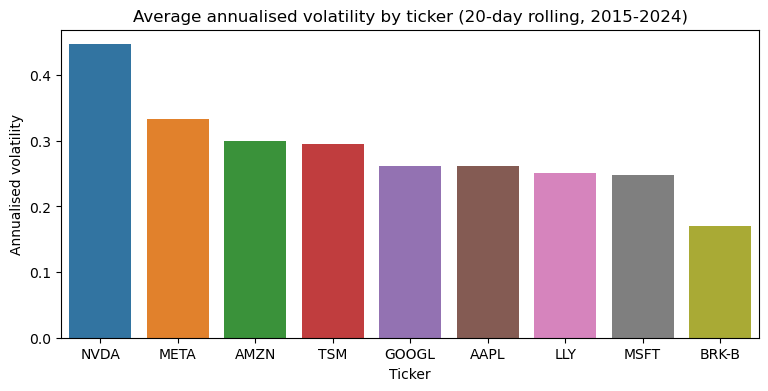

In [ ]:
# Plot 2: average annualised volatility by ticker
vol_summary = (
    df.groupby("Ticker")["Volatility_20d"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 4))
sns.barplot(data=vol_summary, x="Ticker", y="Volatility_20d",
            hue="Ticker", legend=False)
plt.title("Average annualised volatility by ticker (20-day rolling, 2015-2024)")
plt.xlabel("Ticker")
plt.ylabel("Annualised volatility")
plt.show()

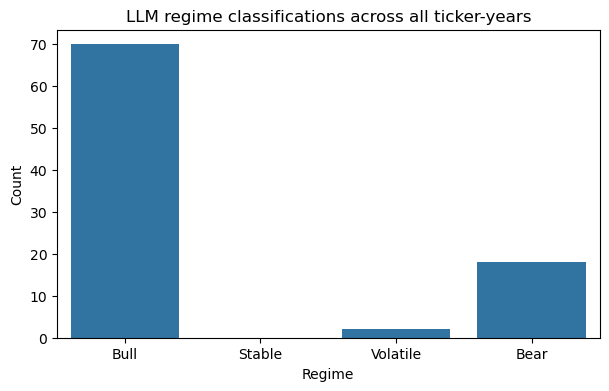

In [ ]:
# Plot 3: distribution of the regime labels that the LLM assigned
plt.figure(figsize=(7, 4))
sns.countplot(data=yearly, x="regime", order=["Bull", "Stable", "Volatile", "Bear"])
plt.title("LLM regime classifications across all ticker-years")
plt.xlabel("Regime")
plt.ylabel("Count")
plt.show()

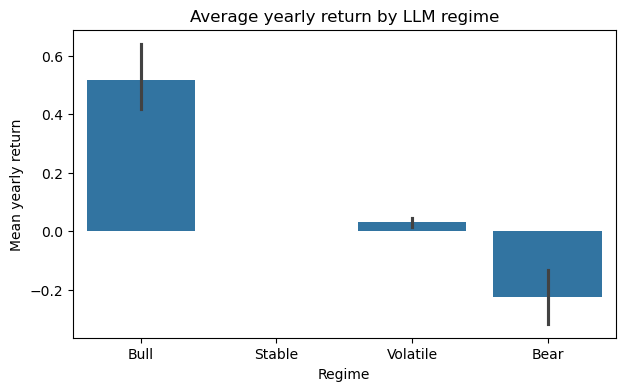

In [28]:
# Plot 4: average yearly return by regime. Doing this to check that the LLM labels make sense
plt.figure(figsize=(7, 4))
sns.barplot(data=yearly, x="regime", y="yearly_return",
            order=["Bull", "Stable", "Volatile", "Bear"])
plt.title("Average yearly return by LLM regime")
plt.xlabel("Regime")
plt.ylabel("Mean yearly return")
plt.show()

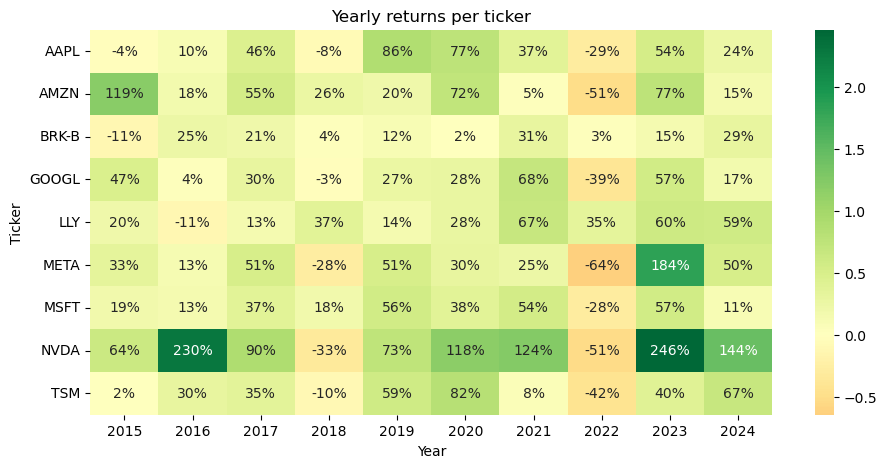

In [29]:
# Plot 5: heatmap of yearly returns per ticker per year
pivot = yearly.pivot(index="Ticker", columns="Year", values="yearly_return")

plt.figure(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", center=0)
plt.title("Yearly returns per ticker")
plt.show()

In [30]:
# Summary statistics
yearly[["yearly_return", "mean_volatility", "max_drawdown", "best_day"]].describe().round(4)

,yearly_return,mean_volatility,max_drawdown,best_day
count,90.0000,90.0000,90.0000,90.0000
mean,0.3588,0.2857,-0.0735,0.0902
std,0.5184,0.1047,0.0411,0.0521
min,-0.6445,0.1065,-0.2639,0.0235
25%,0.1030,0.2182,-0.0901,0.0510
50%,0.2864,0.2620,-0.0603,0.0753
75%,0.5654,0.3494,-0.0458,0.1171
max,2.4594,0.6232,-0.0207,0.2981


The mean yearly return across all 90 ticker-years is 36%, which explains why the LLM never picked "Stable". I guess these stocks just haven't had many quiet years.

### Simple linear regression: predicting yearly return from volatility and regime

Now I one-hot encode the regime label and fit a LinearRegression with volatility plus regime as features. 80/20 split plus 5-fold cross-validation, reporting R² and RMSE.

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# One-hot encode regime label
model_df = pd.get_dummies(yearly, columns=["regime"], drop_first=True, dtype=float)

feature_cols = ["mean_volatility"] + [c for c in model_df.columns if c.startswith("regime_")]
X = model_df[feature_cols]
y = model_df["yearly_return"]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Train/test split")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print()

# 5-fold cross-validation for a more reliable estimate
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("5-fold cross-validation")
print(f"R-squared: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"All folds: {[round(s, 4) for s in cv_scores]}")

Train/test split
R-squared: -0.1552
RMSE:      0.3261

5-fold cross-validation
R-squared: 0.0245 (+/- 0.7499)
All folds: [np.float64(0.5145), np.float64(-1.4664), np.float64(0.3993), np.float64(0.2577), np.float64(0.4174)]


In [33]:
# Coefficients to see which features matter most
coefs = pd.DataFrame({"feature": feature_cols, "coefficient": model.coef_}).round(4)
coefs

,feature,coefficient
0,mean_volatility,1.7019
1,regime_Bull,0.9038
2,regime_Volatile,0.4050


Bear is missing on purpose, drop_first=True makes it the reference category. So Bull (0.90) means 90% higher predicted return than a Bear year.

### Final model
Adding in max_drawdown and best_day  

In [37]:
feature_cols_v2 = ["mean_volatility", "max_drawdown", "best_day"] + \
                  [c for c in model_df.columns if c.startswith("regime_")]
X_v2 = model_df[feature_cols_v2]

cv_scores_v2 = cross_val_score(LinearRegression(), X_v2, y, cv=5, scoring="r2")

print("With max_drawdown and best_day added")
print(f"R-squared: {cv_scores_v2.mean():.4f} (+/- {cv_scores_v2.std():.4f})")
print(f"All folds: {[round(s, 4) for s in cv_scores_v2]}")

With max_drawdown and best_day added
R-squared: 0.1206 (+/- 0.5771)
All folds: [np.float64(0.4795), np.float64(-0.886), np.float64(-0.1627), np.float64(0.6559), np.float64(0.5162)]


In [ ]:
# How much each feature affected the prediction in the final model
model_v2 = LinearRegression()
model_v2.fit(X_v2, y)

coefs = pd.DataFrame({
    "feature": feature_cols_v2,
    "coefficient": model_v2.coef_.round(4)
}).sort_values("coefficient", key=abs, ascending=False)

coefs

,feature,coefficient
2,best_day,5.4194
1,max_drawdown,3.6106
3,regime_Bull,0.6422
0,mean_volatility,0.5746
4,regime_Volatile,0.2838


Adding max_drawdown and best_day helped, R² went from 0.02 to 0.12. Biggest predictors are best_day and max_drawdown which makes sense, bigger swings up mean a positive year, deeper drops mean a worse one. regime_Bull at 0.64 means Bull years predict 64% higher return than Bear (still the reference). Small dataset so folds swing a lot but theres some signal.

## Exporting Raw Data and Results

In this section, the cleaned dataset, the LLM classifications, and the model results are exported as CSV files. This allows the data and results to be reused or reviewed without rerunning the entire notebook.

In [38]:
# Cleaned daily prices
df.to_csv("exports/cleaned_prices.csv", index=False)

# Yearly aggregates with regime labels
yearly.to_csv("exports/yearly_with_regimes.csv", index=False)

# Model predictions on the test set
results = pd.DataFrame({"actual": y_test.values, "predicted": y_pred.round(4)})
results.to_csv("exports/model_predictions.csv", index=False)

# Model coefficients
coefs.to_csv("exports/model_coefficients.csv", index=False)

# Summary stats
yearly[["yearly_return", "mean_volatility", "max_drawdown", "best_day"]].describe().to_csv(
    "exports/statistics_summary.csv"
)

print("Files in exports/:")
for f in sorted(os.listdir("exports")):
    print(" -", f)

Files in exports/:
 - cleaned_prices.csv
 - model_coefficients.csv
 - model_predictions.csv
 - raw_prices.csv
 - statistics_summary.csv
 - yearly_with_regimes.csv


## Conclusion

To sum up, in this project I investigated daily stock data for nine large global companies between 2015 and 2024, and used a local LLM to label each ticker-year as Bull, Bear, Volatile, or Stable.

The yearly aggregates showed a wide spread, average yearly return across all 90 ticker-years was around 36% but the std was over 50%. NVDA had the strongest years and basically every ticker had at least one rough year in there.

The LLM labels lined up with the numbers pretty accurately in my opinion: Bull years averaged roughly +50% returns, Bear years around -15%. Interestingly the LLM almost never picked Stable, which makes sense since these big tech stocks rarely had a quiet year.

For the regression I started simple, volatility plus the regime label, and got a mean R² of 0.02 with 5-fold CV, which is not too great. Adding max_drawdown and best_day as features got it up to 0.12, with best_day and max_drawdown ending up as the strongest predictors. regime_Bull at 0.64 means Bull years predict about 64% higher yearly return than Bear years. So the LLM labels actually seem to correspond to what's in the numbers.

The R² is still low overall, which is expected. Predicting yearly stock returns from past performance is always hard and we had only 90 rows, so quite a small sample. The negative R² on a single train/test split vs the positive CV mean really shows how much the result depends on which split you happen to land on.

Future improvements could include adding actual fundamentals data (P/E, EPS, margins) from an API, using a larger LLM for more accurate labels, or extending the analysis to a larger universe of stocks to get a bigger sample. A bigger sample per stock would also help.